In [1]:
# Instalando dependências
!pip install -q transformers datasets evaluate accelerate scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.9 MB/s eta 0:00:00


In [2]:
# Imports
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
# Verificar uso de GPU
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Dispositivo:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Dispositivo: cpu


In [4]:
# Carregar modelo e tokenizer
# num_labels=2 para classificação binária (negativo / positivo)
# ignore_mismatched_sizes=True porque o modelo original tem 5 classes
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    ignore_mismatched_sizes=True
)
model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: nlptown/bert-base-multilingual-uncased-sentiment
Key               | Status   |                                                                                     
------------------+----------+-------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([5, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([5]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(105879, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [5]:
# Carregar dataset IMDB
dataset = load_dataset("imdb")

dataset

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [6]:
# Explorar dataset
print(dataset["train"][0])

df = pd.DataFrame(dataset["train"].select(range(10)))
df

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0
5,I would put this at the top of my list of film...,0
6,Whoever wrote the screenplay for this movie ob...,0
7,"When I first saw a glimpse of this movie, I qu...",0
8,"Who are these ""They""- the actors? the filmmake...",0
9,This is said to be a personal film for Peter B...,0


In [7]:
# Mapear labels para sentimento
label_map = {
    0: "negative",
    1: "positive"
}

def label_to_sentiment(label):
    return label_map[label]

for i in range(5):
    print("Texto:", dataset["train"][i]["text"][:300])
    print("Label:", dataset["train"][i]["label"])
    print("Sentimento:", label_to_sentiment(dataset["train"][i]["label"]))
    print("-" * 80)

Texto: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h
Label: 0
Sentimento: negative
--------------------------------------------------------------------------------
Texto: "I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, that isn't true. I've seen R-rated films with male nudity
Label: 0
Sentimento: negative
--------------------------------------------------------------------------------
Texto: If only to avoid making this type of film in the future. This film is interesting as an experiment but tells no cogent story.<br /><br />One might feel vir

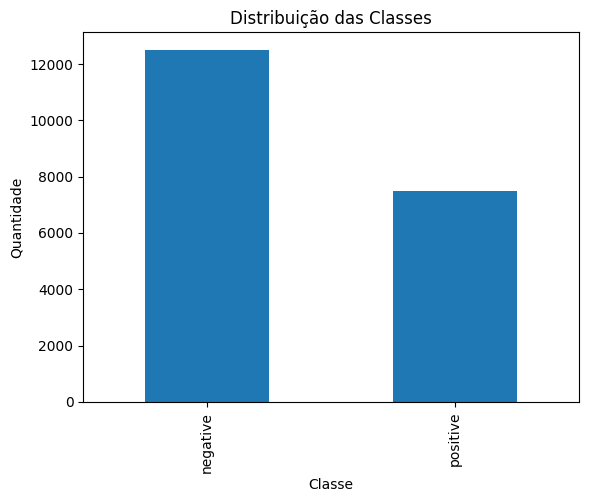

In [8]:
# Distribuição das classes
sample_df = pd.DataFrame(dataset["train"].select(range(20000)))
sample_df["sentiment"] = sample_df["label"].map(label_map)

sample_df["sentiment"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribuição das Classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

In [9]:
# Criar amostras pequenas para Colab
# IMDB não tem split de validação nativo, então usamos uma fatia do train
train_full = dataset["train"].shuffle(seed=42)
train_sample = train_full.select(range(500))
validation_sample = train_full.select(range(500, 700))
test_sample = dataset["test"].shuffle(seed=123).select(range(200))

In [10]:
# Tokenização
def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        max_length=128
    )

tokenized_train = train_sample.map(tokenize_function, batched=True)
tokenized_validation = validation_sample.map(tokenize_function, batched=True)
tokenized_test = test_sample.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [11]:
# Métricas
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [12]:
# Avaliar modelo antes do fine-tuning
initial_args = TrainingArguments(
    output_dir="./initial_results",
    per_device_eval_batch_size=16,
    report_to="none"
)

initial_trainer = Trainer(
    model=model,
    args=initial_args,
    eval_dataset=tokenized_test,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


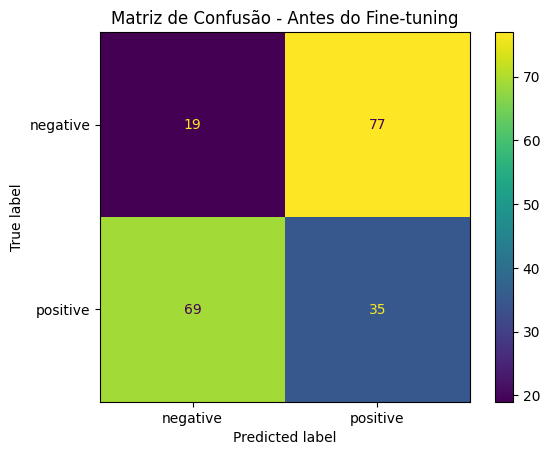

In [13]:
# Matriz de confusão antes do fine-tuning (3min)
initial_predictions = initial_trainer.predict(tokenized_test)

y_true = initial_predictions.label_ids
y_pred = np.argmax(initial_predictions.predictions, axis=-1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative", "positive"]
)

disp.plot(cmap=None)
plt.title("Matriz de Confusão - Antes do Fine-tuning")
plt.show()

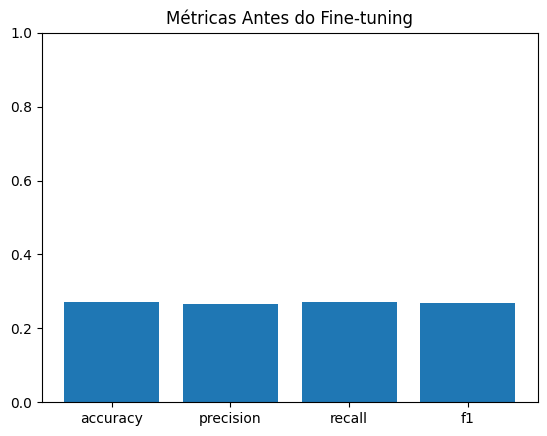

{'accuracy': 0.27,
 'precision': 0.2661363636363636,
 'recall': 0.27,
 'f1': 0.2676489533011272}

In [14]:
# Gráfico de métricas antes do fine-tuning
accuracy = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted"
)

metrics_before = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1
}

plt.bar(metrics_before.keys(), metrics_before.values())
plt.title("Métricas Antes do Fine-tuning")
plt.ylim(0, 1)
plt.show()

metrics_before

In [15]:
# Configurar fine-tuning
training_args = TrainingArguments(
    output_dir="./sentiment_model_imdb_finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

In [16]:
# Fine-tuning (16 min)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.471174,0.434686,0.815000,0.830666,0.815000,0.815440


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=63, training_loss=0.44761560833643355, metrics={'train_runtime': 961.7931, 'train_samples_per_second': 0.52, 'train_steps_per_second': 0.066, 'total_flos': 32888881920000.0, 'train_loss': 0.44761560833643355, 'epoch': 1.0})

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


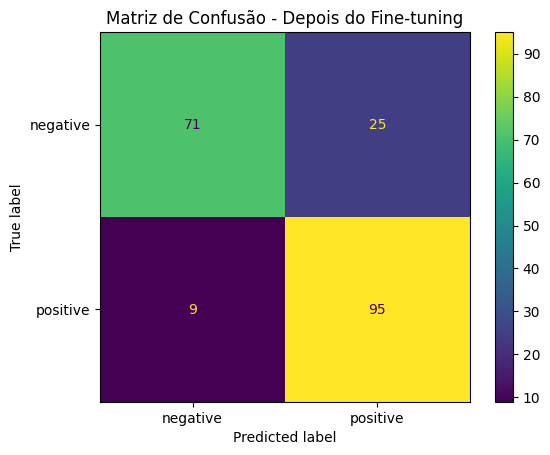

In [17]:
# Matriz de confusão depois do fine-tuning
final_predictions = trainer.predict(tokenized_test)

y_true_final = final_predictions.label_ids
y_pred_final = np.argmax(final_predictions.predictions, axis=-1)

cm_final = confusion_matrix(y_true_final, y_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["negative", "positive"]
)

disp.plot(cmap=None)
plt.title("Matriz de Confusão - Depois do Fine-tuning")
plt.show()

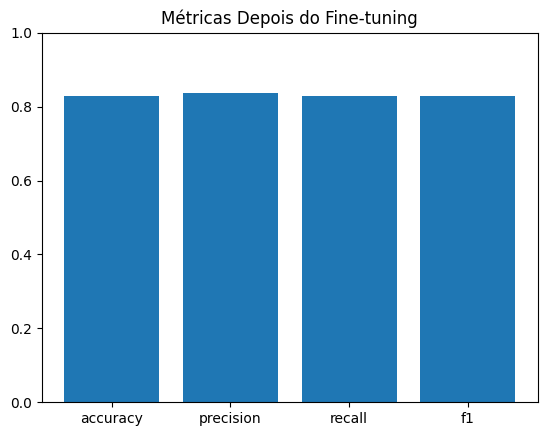

{'accuracy': 0.83,
 'precision': 0.8376666666666666,
 'recall': 0.83,
 'f1': 0.8283441558441558}

In [18]:
# Métricas depois do fine-tuning
accuracy_after = accuracy_score(y_true_final, y_pred_final)

precision_after, recall_after, f1_after, _ = precision_recall_fscore_support(
    y_true_final,
    y_pred_final,
    average="weighted"
)

metrics_after = {
    "accuracy": accuracy_after,
    "precision": precision_after,
    "recall": recall_after,
    "f1": f1_after
}

plt.bar(metrics_after.keys(), metrics_after.values())
plt.title("Métricas Depois do Fine-tuning")
plt.ylim(0, 1)
plt.show()

metrics_after

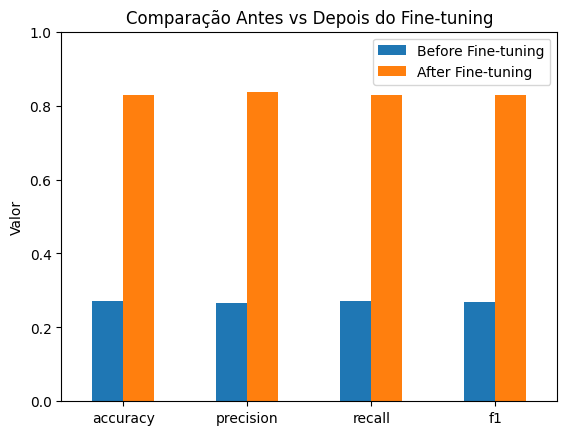

,Before Fine-tuning,After Fine-tuning
accuracy,0.270000,0.830000
precision,0.266136,0.837667
recall,0.270000,0.830000
f1,0.267649,0.828344


In [19]:
# Comparação antes vs depois
comparison_df = pd.DataFrame({
    "Before Fine-tuning": metrics_before,
    "After Fine-tuning": metrics_after
})

comparison_df.plot(kind="bar")

plt.title("Comparação Antes vs Depois do Fine-tuning")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

comparison_df

In [20]:
# Função para prever sentimento de filmes
def predict_sentiment(text):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
    predicted_class = torch.argmax(probabilities, dim=-1).item()
    confidence = probabilities[0][predicted_class].item()

    return {
        "text": text,
        "predicted_label": predicted_class,
        "sentiment": label_to_sentiment(predicted_class),
        "confidence": round(confidence, 4)
    }

In [21]:
# Testar exemplos de filmes
examples = [
    "This movie was absolutely fantastic! The acting was superb and the story kept me on the edge of my seat.",
    "Terrible film. I wasted two hours of my life watching this disaster. Avoid at all costs.",
    "It was okay, nothing special. Some good scenes but overall forgettable.",
    "One of the best movies I've ever seen. A masterpiece of cinema!",
    "Boring, predictable plot. The characters were flat and the dialogue was awful."
]

for example in examples:
    result = predict_sentiment(example)
    print(result)

{'text': 'This movie was absolutely fantastic! The acting was superb and the story kept me on the edge of my seat.', 'predicted_label': 1, 'sentiment': 'positive', 'confidence': 0.8986}
{'text': 'Terrible film. I wasted two hours of my life watching this disaster. Avoid at all costs.', 'predicted_label': 0, 'sentiment': 'negative', 'confidence': 0.9371}
{'text': 'It was okay, nothing special. Some good scenes but overall forgettable.', 'predicted_label': 0, 'sentiment': 'negative', 'confidence': 0.7457}
{'text': "One of the best movies I've ever seen. A masterpiece of cinema!", 'predicted_label': 1, 'sentiment': 'positive', 'confidence': 0.8952}
{'text': 'Boring, predictable plot. The characters were flat and the dialogue was awful.', 'predicted_label': 0, 'sentiment': 'negative', 'confidence': 0.9408}


In [22]:
# Salvar modelo treinado
model.save_pretrained("./modelo_imdb_finetuned")
tokenizer.save_pretrained("./modelo_imdb_finetuned")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./modelo_imdb_finetuned/tokenizer_config.json',
 './modelo_imdb_finetuned/tokenizer.json')